In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from aeon.datasets import load_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

In [ ]:
# ============================================================
# 1) Utilities
# ============================================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def resize_1d_series(x, target_length):
    old_idx = np.linspace(0, 1, len(x))
    new_idx = np.linspace(0, 1, target_length)
    return np.interp(new_idx, old_idx, x).astype(np.float32)

def make_loader(X, y, batch_size=16, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def accuracy(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    return accuracy_score(targets, preds)

In [ ]:
# ============================================================
# 2) Task abstraction
# ============================================================
@dataclass
class TimeSeriesTask:
    name: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray

class AeonTaskLoader:
    def __init__(self, target_length=150, only_first_channel=True):
        self.target_length = target_length
        self.only_first_channel = only_first_channel

    def load_task(self, dataset_name):
        X_train, y_train = load_classification(dataset_name, split="train")
        X_test, y_test = load_classification(dataset_name, split="test")

        if X_train.ndim == 3:
            if self.only_first_channel:
                X_train = X_train[:, 0, :]
                X_test = X_test[:, 0, :]
            else:
                raise ValueError("Multivariate handling not implemented yet.")
        elif X_train.ndim != 2:
            raise ValueError(f"Unexpected shape for {dataset_name}: {X_train.shape}")

        # Resize to common length
        X_train = np.array([resize_1d_series(x, self.target_length) for x in X_train], dtype=np.float32)
        X_test = np.array([resize_1d_series(x, self.target_length) for x in X_test], dtype=np.float32)

        # Encode labels
        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)

        n_classes = len(np.unique(y_train))
        if n_classes != 2:
            raise ValueError(f"{dataset_name} is not binary. Found {n_classes} classes.")

        # Standardize per task
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train).astype(np.float32)
        X_test = scaler.transform(X_test).astype(np.float32)

        return TimeSeriesTask(
            name=dataset_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test
        )

    def load_sequence(self, dataset_names):
        return [self.load_task(name) for name in dataset_names]

In [ ]:
# ============================================================
# 3) Model
# ============================================================
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def extract_features(self, x):
        return self.relu(self.fc1(x))

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.fc2(feats)
        return logits

In [ ]:
# ============================================================
# 4) Base continual learning strategy
# ============================================================
class BaseStrategy:
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.ce_loss = nn.CrossEntropyLoss()

    def train_epoch(self, loader, extra_loss_fn=None):
        self.model.train()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)

            if extra_loss_fn is not None:
                loss = loss + extra_loss_fn(xb, yb, logits)

            loss.backward()
            self.optimizer.step()

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        for _ in range(self.epochs):
            self.train_epoch(loader)

    def evaluate_task(self, task):
        loader = make_loader(task.X_test, task.y_test, batch_size=self.batch_size, shuffle=False)
        return accuracy(self.model, loader, self.device)

In [ ]:
# ============================================================
# 5) Baseline strategy
# ============================================================
class BaselineStrategy(BaseStrategy):
    pass

In [ ]:
# ============================================================
# 6) EWC strategy
# ============================================================
class EWCStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, ewc_lambda=200.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.ewc_lambda = ewc_lambda
        self.fisher = None
        self.old_params = None

    def compute_fisher(self, task):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        fisher = {n: torch.zeros_like(p) for n, p in self.model.named_parameters()}

        self.model.eval()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            self.model.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)
            loss.backward()

            for n, p in self.model.named_parameters():
                if p.grad is not None:
                    fisher[n] += p.grad.detach() ** 2

        for n in fisher:
            fisher[n] /= len(loader)

        return fisher

    def save_old_params(self):
        self.old_params = {n: p.detach().clone() for n, p in self.model.named_parameters()}

    def ewc_penalty(self):
        if self.fisher is None or self.old_params is None:
            return 0.0

        penalty = 0.0
        for n, p in self.model.named_parameters():
            penalty += (self.fisher[n] * (p - self.old_params[n]) ** 2).sum()
        return 0.5 * self.ewc_lambda * penalty

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.ewc_penalty()

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.fisher = self.compute_fisher(task)
        self.save_old_params()

In [ ]:
# ============================================================
# 7) LwF strategy
# ============================================================
class LwFStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, alpha=1.0, temperature=2.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha = alpha
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")

    def distillation_loss(self, xb, logits):
        if self.teacher is None:
            return 0.0

        with torch.no_grad():
            teacher_logits = self.teacher(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        return self.alpha * self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distillation_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 8) Replay strategy
# ============================================================
class ReplayStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, replay_per_class=100):
        super().__init__(model, device, lr, batch_size, epochs)
        self.replay_per_class = replay_per_class
        self.replay_stats = None

    def fit_class_gaussians(self, X, y):
        stats = {}
        for c in np.unique(y):
            Xc = X[y == c]
            mean = Xc.mean(axis=0)
            var = Xc.var(axis=0) + 1e-4
            stats[c] = (mean, var)
        return stats

    def sample_replay(self):
        Xs, ys = [], []
        for c, (mean, var) in self.replay_stats.items():
            samples = np.random.randn(self.replay_per_class, len(mean)) * np.sqrt(var) + mean
            Xs.append(samples.astype(np.float32))
            ys.append(np.full(self.replay_per_class, c))
        return np.vstack(Xs), np.concatenate(ys)

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)
            self.replay_stats = self.fit_class_gaussians(task.X_train, task.y_train)
        else:
            X_replay, y_replay = self.sample_replay()
            X_mix = np.vstack([task.X_train, X_replay]).astype(np.float32)
            y_mix = np.concatenate([task.y_train, y_replay])

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.replay_stats = self.fit_class_gaussians(X_mix, y_mix)

In [ ]:
# ============================================================
# 8) TS-Feature Distill Strategy (improved LwF)
# ============================================================
class TSFeatureDistillStrategy(BaseStrategy):
    def __init__(
        self,
        model,
        device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        alpha_logits=1.0,
        alpha_features=1.0,
        temperature=2.0,
    ):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha_logits = alpha_logits
        self.alpha_features = alpha_features
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")
        self.mse = nn.MSELoss()

    def distill_loss(self, xb, logits):
        if self.teacher is None:
            return 0.0

        with torch.no_grad():
            teacher_logits = self.teacher(xb)
            teacher_feats = self.teacher.extract_features(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        logit_loss = self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

        student_feats = self.model.extract_features(xb)
        feat_loss = self.mse(student_feats, teacher_feats)

        return self.alpha_logits * logit_loss + self.alpha_features * feat_loss

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distill_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 8) TS-Proto Replay Strategy (feature-space prototype)
# ============================================================
class TSProtoReplayStrategy(BaseStrategy):
    def __init__(
        self,
        model,
        device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        memory_per_class=20,
        alpha_proto=1.0,
    ):
        super().__init__(model, device, lr, batch_size, epochs)
        self.memory_per_class = memory_per_class
        self.alpha_proto = alpha_proto
        self.memory_X = []
        self.memory_y = []
        self.prototypes = {}
        self.mse = nn.MSELoss()

    def update_memory(self, X, y):
        mem_X, mem_y = [], []
        classes = np.unique(y)

        for c in classes:
            Xc = X[y == c]
            idx = np.random.choice(len(Xc), size=min(self.memory_per_class, len(Xc)), replace=False)
            mem_X.append(Xc[idx])
            mem_y.append(np.full(len(idx), c))

        mem_X = np.vstack(mem_X).astype(np.float32)
        mem_y = np.concatenate(mem_y)

        self.memory_X.append(mem_X)
        self.memory_y.append(mem_y)

    def get_memory(self):
        if len(self.memory_X) == 0:
            return None, None
        X_mem = np.vstack(self.memory_X).astype(np.float32)
        y_mem = np.concatenate(self.memory_y)
        return X_mem, y_mem

    def update_prototypes(self):
        X_mem, y_mem = self.get_memory()
        if X_mem is None:
            return

        self.model.eval()
        X_t = torch.tensor(X_mem, dtype=torch.float32).to(self.device)
        y_t = torch.tensor(y_mem, dtype=torch.long).to(self.device)

        with torch.no_grad():
            feats = self.model.extract_features(X_t)

        self.prototypes = {}
        for c in torch.unique(y_t):
            mask = y_t == c
            proto = feats[mask].mean(dim=0)
            self.prototypes[int(c.item())] = proto.detach().clone()

    def prototype_loss(self, xb, yb):
        if len(self.prototypes) == 0:
            return 0.0

        feats = self.model.extract_features(xb)
        loss = 0.0
        count = 0

        for c, proto in self.prototypes.items():
            mask = (yb == c)
            if mask.sum() > 0:
                loss += self.mse(feats[mask].mean(dim=0), proto.to(self.device))
                count += 1

        if count == 0:
            return 0.0
        return self.alpha_proto * loss / count

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()
        else:
            X_mem, y_mem = self.get_memory()

            if X_mem is not None:
                X_mix = np.vstack([task.X_train, X_mem]).astype(np.float32)
                y_mix = np.concatenate([task.y_train, y_mem])
            else:
                X_mix, y_mix = task.X_train, task.y_train

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)

            def extra_loss_fn(xb, yb, logits):
                return self.prototype_loss(xb, yb)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()

In [ ]:
# ============================================================
# 9) Metrics
# ============================================================
def compute_accuracy_matrix(strategy, tasks):
    n_tasks = len(tasks)
    acc_matrix = np.zeros((n_tasks, n_tasks))

    for trained_up_to in range(n_tasks):
        for eval_task in range(trained_up_to + 1):
            acc_matrix[trained_up_to, eval_task] = strategy.evaluate_task(tasks[eval_task])

    return acc_matrix

def final_average_accuracy(acc_matrix):
    last_row = acc_matrix[-1]
    non_zero = last_row[last_row > 0]
    return non_zero.mean()

def final_forgetting(acc_matrix):
    n_tasks = acc_matrix.shape[1]
    forgetting = []

    for t in range(n_tasks - 1):
        best_before = np.max(acc_matrix[:-1, t])
        final_acc = acc_matrix[-1, t]
        forgetting.append(best_before - final_acc)

    return np.mean(forgetting) if len(forgetting) > 0 else 0.0

In [ ]:
# ============================================================
# 10) Experiment runner
# ============================================================
class ContinualLearningExperiment:
    def __init__(self, tasks, strategy_dict):
        self.tasks = tasks
        self.strategy_dict = strategy_dict
        self.results = {}

    def run(self):
        for name, strategy in self.strategy_dict.items():
            print(f"\nRunning strategy: {name}")
            n_tasks = len(self.tasks)
            acc_matrix = np.zeros((n_tasks, n_tasks))

            for task_id, task in enumerate(self.tasks):
                print(f"  Training on task {task_id+1}: {task.name}")
                strategy.fit_task(task, task_id=task_id)

                for eval_id in range(task_id + 1):
                    acc = strategy.evaluate_task(self.tasks[eval_id])
                    acc_matrix[task_id, eval_id] = acc
                    print(f"    Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

            self.results[name] = acc_matrix

        return self.results

    def summary(self):
        rows = []
        for name, acc_matrix in self.results.items():
            rows.append({
                "method": name,
                "final_avg_acc": final_average_accuracy(acc_matrix),
                "final_forgetting": final_forgetting(acc_matrix)
            })
        return pd.DataFrame(rows)

In [ ]:
# ============================================================
# 11) Plotting
# ============================================================
def plot_accuracy_matrices(results, task_names):
    for method, acc_matrix in results.items():
        plt.figure(figsize=(6, 4))
        plt.imshow(acc_matrix, cmap="Blues", vmin=0, vmax=1)
        plt.colorbar(label="Accuracy")
        plt.xticks(range(len(task_names)), task_names, rotation=45)
        plt.yticks(range(len(task_names)), [f"After T{i+1}" for i in range(len(task_names))])
        plt.title(f"Accuracy Matrix - {method}")
        plt.tight_layout()
        plt.show()

/tmp/ipykernel_2363/170783264.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_2363/170783264.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_2363/170783264.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/


Running strategy: Baseline
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8800
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.7067
    Eval on task 2 (SonyAIBORobotSurface1): 0.7671

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8600
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8533
    Eval on task 2 (SonyAIBORobotSurface1): 0.7371

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8467
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.9000
    Eval on task 2 (SonyAIBORobotSurface1): 0.6240

Running strategy: Replay
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8400
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8133
    Eval on task 2 (SonyAIBORobotSurface1): 0.6905

Running strategy: TS-FeatureDistill
  Training on task 1: GunPoint
    Eval on task 1 (GunP

,method,final_avg_acc,final_forgetting
0,Baseline,0.736861,0.173333
1,EWC,0.795219,0.006667
2,LwF,0.761980,-0.053333
3,Replay,0.751925,0.026667
4,TS-FeatureDistill,0.731126,0.040000
5,TS-ProtoReplay,0.819379,-0.033333


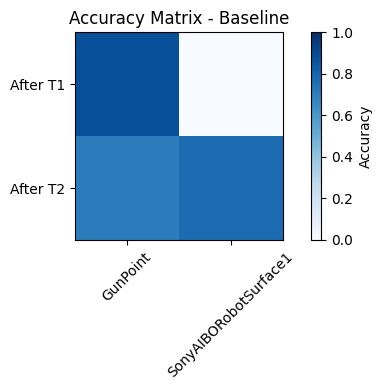

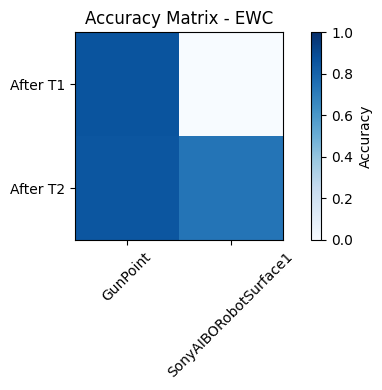

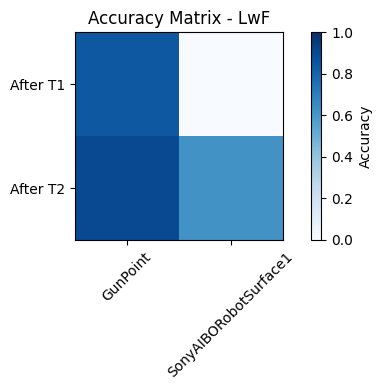

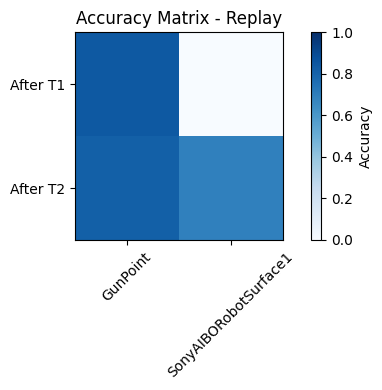

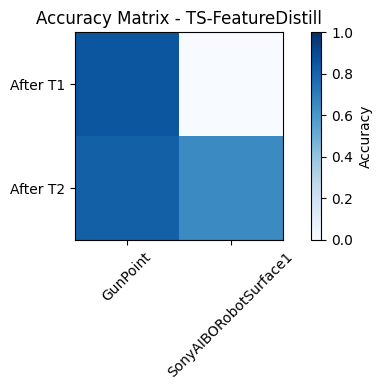

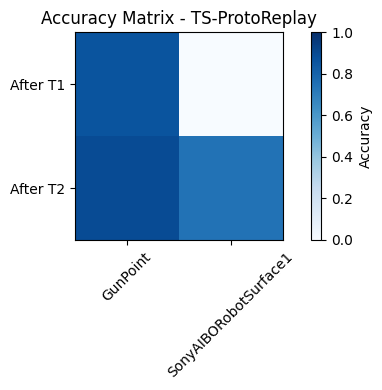

In [ ]:
# ============================================================
# 12) Example usage
# ============================================================
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

task_loader = AeonTaskLoader(target_length=150)

task_names = ["GunPoint", "SonyAIBORobotSurface1"]
tasks = task_loader.load_sequence(task_names)

input_dim = tasks[0].X_train.shape[1]

strategies = {
    "Baseline": BaselineStrategy(
        model=FeatureMLP(input_dim=input_dim, hidden_dim=64, num_classes=2),
        device=device,
        lr=1e-3,
        batch_size=16,
        epochs=30
    ),
    "EWC": EWCStrategy(
        model=FeatureMLP(input_dim=input_dim, hidden_dim=64, num_classes=2),
        device=device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        ewc_lambda=200.0
    ),
    "LwF": LwFStrategy(
        model=FeatureMLP(input_dim=input_dim, hidden_dim=64, num_classes=2),
        device=device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        alpha=1.0,
        temperature=2.0
    ),
    "Replay": ReplayStrategy(
        model=FeatureMLP(input_dim=input_dim, hidden_dim=64, num_classes=2),
        device=device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        replay_per_class=100
    ),
    "TS-FeatureDistill": TSFeatureDistillStrategy(
        model=FeatureMLP(input_dim=input_dim, hidden_dim=64, num_classes=2),
        device=device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        alpha_logits=1.0,
        alpha_features=0.5,
        temperature=2.0
    ),
    "TS-ProtoReplay": TSProtoReplayStrategy(
        model=FeatureMLP(input_dim=input_dim, hidden_dim=64, num_classes=2),
        device=device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        memory_per_class=20,
        alpha_proto=0.5
    ),
}

experiment = ContinualLearningExperiment(tasks, strategies)
results = experiment.run()

print("\nSummary:")
summary_df = experiment.summary()
display(summary_df)

plot_accuracy_matrices(results, task_names)